/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 80ms/step - accuracy: 0.3869 - loss: 1.4052 - val_accuracy: 0.5123 - val_loss: 1.1953
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5324 - loss: 1.1356 - val_accuracy: 0.6076 - val_loss: 0.9253
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.6202 - loss: 0.9898 - val_accuracy: 0.6485 - val_loss: 0.9145
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.6713 - loss: 0.8715 - val_accuracy: 0.6907 - val_loss: 0.8446
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.7040 - loss: 0.7644 - val_accuracy: 0.6417 - val_loss: 0.9254
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.7381 - loss: 0.6835 - val_accuracy: 0.7003 - val_loss: 0.7903
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7749 - loss: 0.6061 - val_accuracy: 0.7098 - val_loss: 0.7371
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.8123 - loss: 0.4947 - val_accuracy: 0.7316 - 

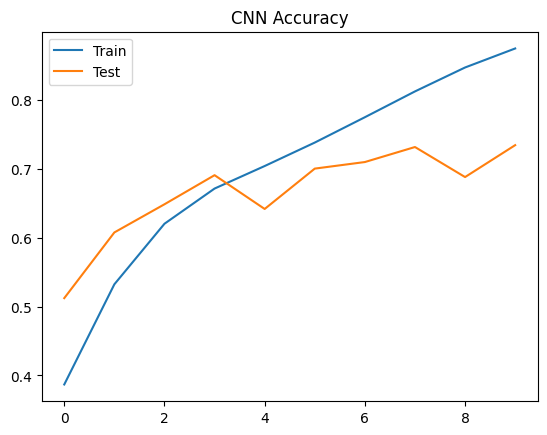

In [27]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Load dataset
dataset, info = tfds.load('tf_flowers', split='train', as_supervised=True, with_info=True)
images, labels = [], []
for img, label in tfds.as_numpy(dataset):
    img = tf.image.resize(img, (128,128))
    images.append(img.numpy())
    labels.append(label)

images = np.array(images) / 255.0
labels = np.array(labels)

# Split 80:20
split = int(0.8 * len(images))
x_train, x_test = images[:split], images[split:]
y_train, y_test = labels[:split], labels[split:]

# Build CNN model
cnn_model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(5, activation='softmax')
])

cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Train CNN
history = cnn_model.fit(
    x_train, y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

# Evaluate
test_loss, test_acc = cnn_model.evaluate(x_test, y_test)
print("CNN Test Accuracy:", test_acc)

# Plot accuracy
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Test')
plt.title("CNN Accuracy")
plt.legend()
plt.show()


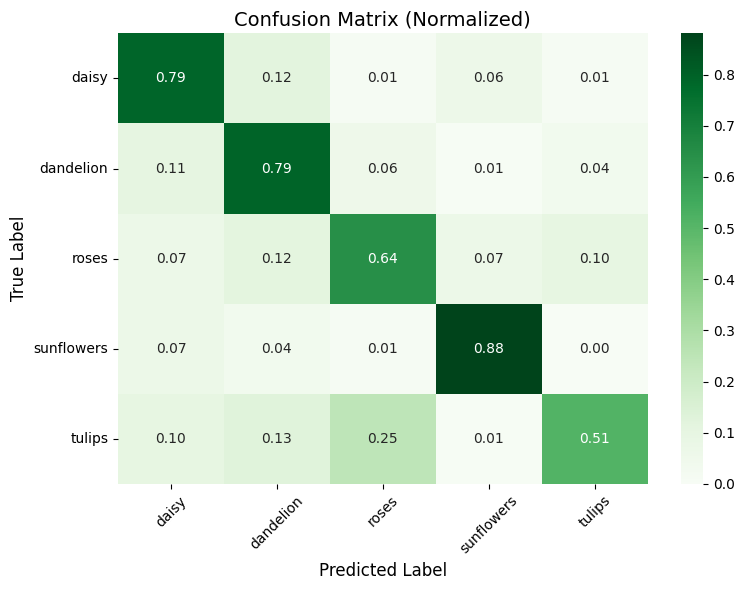

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Normalize
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

class_names = ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True
)

plt.title("Confusion Matrix (Normalized)", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Saving A6_efb80bf9-7531-4cb5-bd45-6eea6a5fe9df.csv to A6_efb80bf9-7531-4cb5-bd45-6eea6a5fe9df (1).csv
Columns in dataset: Index(['Close'], dtype='object')
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0086 - val_loss: 0.0018
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 3.5752e-04 - val_loss: 0.0016
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 3.0792e-04 - val_loss: 0.0018
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 2.9766e-04 - val_loss: 0.0015
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 3.1893e-04 - val_loss: 0.0016
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 3.2663e-04 - val_loss: 0.0014
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2.6204e-04 - val_loss: 0.0013
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 2.5348e-04 - val_loss: 0.0013
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 2.3510e-04 - val_loss: 0.0012
Epoch 10/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 2.3862e-04 - val_loss: 0.0011
Epoch 11/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 2.5897e-04 - val_loss: 0.0025
Epoch 12/20
49/49 ━━━━━━━━━━━━━━━━

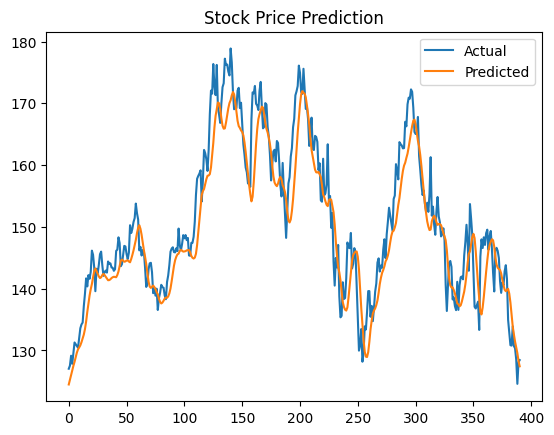

In [29]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

AUTOTUNE = tf.data.AUTOTUNE
from google.colab import files
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print("Columns in dataset:", df.columns)

# CHANGE COLUMN NAME HERE IF NEEDED
data = df['Close'].values.reshape(-1,1)

# Normalize
scaler = MinMaxScaler()
data = scaler.fit_transform(data)

# Create sequences
X, y = [], []
for i in range(60, len(data)):
    X.append(data[i-60:i])
    y.append(data[i])

X, y = np.array(X), np.array(y)

# Split 80:20
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Build RNN model
rnn_model = keras.Sequential([
    layers.LSTM(50, return_sequences=True, input_shape=(60,1)),
    layers.LSTM(50),
    layers.Dense(25),
    layers.Dense(1)
])

rnn_model.compile(optimizer='adam', loss='mse')

# Train RNN
rnn_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# Predict
predictions = rnn_model.predict(X_test)

# Inverse transform
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

# Plot results
plt.plot(y_test_actual, label='Actual')
plt.plot(predictions, label='Predicted')
plt.title("Stock Price Prediction")
plt.legend()
plt.show()